In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [2]:
total_keys2 = ["L_MASS",'Lb_MASS','Jpsi_MASS','Jpsi_P', "Jpsi_PT",'Jpsi_CHI2','Jpsi_MAXDOCA','Jpsi_BPVDIRA','Jpsi_END_VRHO','Jpsi_END_VX','Jpsi_END_VY','Jpsi_END_VZ','Jpsi_BPVIP','Jpsi_MINIPCHI2','L_P','L_PT','L_PX','L_PY','L_PZ','L_CHI2',
               'L_END_VZ','L_END_VX','L_END_VY',"L_END_VRHO","L_BPVDIRA","L_BPVIP","L_BPVIPCHI2",'L_BPVFDCHI2','L_MINIPCHI2',"Lb_P","Lb_PT",'Lb_PX','Lb_PY','Lb_PZ',"Lb_CHI2","Lb_MAXDOCA","Lb_BPVDIRA","Lb_BPVVDRHO",
               "Lb_BPVIP",'Lb_BPVIPCHI2','Lb_BPVFDCHI2','Lb_MINIPCHI2',"p_P","p_PT",'p_PX','p_PY','p_PZ',"p_PID_P",
               "p_PID_K","p_MINIP",'p_GHOSTPROB',"pim_P","pim_PT",'pim_PX','pim_PY','pim_PZ','pim_GHOSTPROB','mum_P','mum_PT','mum_PX','mum_PY','mum_PZ','mum_CHI2','mum_GHOSTPROB','mum_PID_P','mum_PID_K','mum_PID_MU',
               'mum_PID_E','mum_MINIP','mum_MINIPCHI2','mup_P','mup_PT','mup_PX','mup_PY','mup_PZ','mup_CHI2','mup_GHOSTPROB','mup_PID_P','mup_PID_K','mup_PID_MU','mup_PID_E','mup_MINIP','mup_MINIPCHI2',
               'totCandidates']

In [3]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '


second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [4]:
import subprocess
data_dir = "/l/izaac/data/24mc/jpsiLambda/md"
result = subprocess.run(['ls', data_dir], stdout=subprocess.PIPE, text=True)
file_list = [data_dir+"/"+file_path+":Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree" for file_path in result.stdout.split('\n') if file_path]

print(file_list)

['/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree', '/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree']


In [5]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data2 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data3 = my_tuple_mc_1.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data4 = my_tuple_mc_2.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_data5 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'], library="pd", cut="(Lb_BKGCAT==0)")
mc_data6 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'],library="pd", cut="(Lb_BKGCAT==0)")
mc_data7 = my_tuple_mc_3.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'], library="pd", cut="(Lb_BKGCAT!=0)")
mc_data8 = my_tuple_mc_4.arrays(total_keys2 + ['Lb_BKGCAT']+['p_QOVERP', 'pim_QOVERP', 'Lb_END_VX','Lb_END_VY','Lb_END_VZ','L_TRUEP','L_TRUEPX','L_TRUEPY','L_TRUEPZ','p_TRUEP','p_TRUEPX','p_TRUEPY','p_TRUEPZ','pim_TRUEP','pim_TRUEPX','pim_TRUEPY','pim_TRUEPZ','L_TRUEID','pim_TRUEID','p_TRUEID','p_TRUEENERGY','pim_TRUEENERGY','L_TRUEENERGY','p_MC_GD_MOTHER_ID','p_MC_MOTHER_ID','pim_MC_GD_MOTHER_ID','pim_MC_MOTHER_ID','L_ENERGY','p_ENERGY','pim_ENERGY','p_TRACK_POS_CLOSESTTOBEAM_X','p_TRACK_POS_CLOSESTTOBEAM_Y','p_TRACK_POS_CLOSESTTOBEAM_Z','pim_TRACK_POS_CLOSESTTOBEAM_X','pim_TRACK_POS_CLOSESTTOBEAM_Y','pim_TRACK_POS_CLOSESTTOBEAM_Z'],library="pd", cut="(Lb_BKGCAT!=0)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_background = mc_background_merge.query(preselection_cut_mc)
mc_signal_background = mc_signal_background_merge.query(preselection_cut_mc)



In [6]:
# signal_data1 = my_tuple1.arrays(total_keys2,library="pd")
# signal_data2 = my_tuple2.arrays(total_keys2,library="pd")
# signal_data3 = my_tuple3.arrays(total_keys2,library="pd")
# signal_data4 = my_tuple4.arrays(total_keys2,library="pd")
# signal_data5 = my_tuple5.arrays(total_keys2,library="pd")
# signal_data6 = my_tuple6.arrays(total_keys2,library="pd")
# signal_data7 = my_tuple7.arrays(total_keys2,library="pd")
# signal_data8 = my_tuple8.arrays(total_keys2,library="pd")
# signal_data9 = my_tuple9.arrays(total_keys2,library="pd")
# signal_data10 = my_tuple10.arrays(total_keys2,library="pd")


# signal_data21 = my_tuple21.arrays(total_keys2,library="pd")
# signal_data22 = my_tuple22.arrays(total_keys2,library="pd")
# signal_data23 = my_tuple23.arrays(total_keys2,library="pd")
# signal_data24 = my_tuple24.arrays(total_keys2,library="pd")
# signal_data25 = my_tuple25.arrays(total_keys2,library="pd")
# signal_data26 = my_tuple26.arrays(total_keys2,library="pd")
# signal_data27 = my_tuple27.arrays(total_keys2,library="pd")
# signal_data28 = my_tuple28.arrays(total_keys2,library="pd")
# signal_data29 = my_tuple29.arrays(total_keys2,library="pd")
# signal_data30 = my_tuple30.arrays(total_keys2,library="pd")

In [7]:
# signal_data1_cut = signal_data1.query(preselection_cut)
# signal_data2_cut = signal_data2.query(preselection_cut)
# signal_data3_cut = signal_data3.query(preselection_cut)
# signal_data4_cut = signal_data4.query(preselection_cut)
# signal_data5_cut = signal_data5.query(preselection_cut)
# signal_data6_cut = signal_data6.query(preselection_cut)
# signal_data7_cut = signal_data7.query(preselection_cut)
# signal_data8_cut = signal_data8.query(preselection_cut)
# signal_data9_cut = signal_data9.query(preselection_cut)
# signal_data10_cut = signal_data10.query(preselection_cut)

# signal_data21_cut = signal_data21.query(preselection_cut)
# signal_data22_cut = signal_data22.query(preselection_cut)
# signal_data23_cut = signal_data23.query(preselection_cut)
# signal_data24_cut = signal_data24.query(preselection_cut)
# signal_data25_cut = signal_data25.query(preselection_cut)
# signal_data26_cut = signal_data26.query(preselection_cut)
# signal_data27_cut = signal_data27.query(preselection_cut)
# signal_data28_cut = signal_data28.query(preselection_cut)
# signal_data29_cut = signal_data29.query(preselection_cut)
# signal_data30_cut = signal_data30.query(preselection_cut)

In [8]:
# signal_data12_cut = pd.merge(signal_data1_cut,signal_data2_cut, how="outer")
# signal_data34_cut = pd.merge(signal_data3_cut,signal_data4_cut, how="outer")
# signal_data56_cut = pd.merge(signal_data5_cut,signal_data6_cut, how="outer")
# signal_data78_cut = pd.merge(signal_data7_cut,signal_data8_cut, how="outer")
# signal_data9_10_cut = pd.merge(signal_data9_cut,signal_data10_cut, how="outer")
# signal_data1234_cut = pd.merge(signal_data12_cut,signal_data34_cut, how="outer")
# signal_data5678_cut = pd.merge(signal_data56_cut,signal_data78_cut, how="outer")
# signal_data12345678_cut = pd.merge(signal_data1234_cut,signal_data5678_cut, how="outer")
# signal_data_first_10_cut = pd.merge(signal_data12345678_cut,signal_data9_10_cut, how="outer")

# signal_data2122_cut = pd.merge(signal_data21_cut,signal_data2_cut, how="outer")
# signal_data2324_cut = pd.merge(signal_data23_cut,signal_data24_cut, how="outer")
# signal_data2526_cut = pd.merge(signal_data26_cut,signal_data25_cut, how="outer")
# signal_data2728_cut = pd.merge(signal_data27_cut,signal_data28_cut, how="outer")
# signal_data29_30_cut = pd.merge(signal_data29_cut,signal_data30_cut, how="outer")
# signal_data21222324_cut = pd.merge(signal_data2122_cut,signal_data2324_cut, how="outer")
# signal_data25262728_cut = pd.merge(signal_data2526_cut,signal_data2728_cut, how="outer")
# signal_data2122232425262728_cut = pd.merge(signal_data21222324_cut,signal_data25262728_cut, how="outer")
# signal_data_last_10_cut = pd.merge(signal_data2122232425262728_cut,signal_data29_30_cut, how="outer")

# signal_data =  pd.merge(signal_data_first_10_cut,signal_data_last_10_cut, how="outer")
 

In [9]:
#Preselection data.
signal_data = pd.read_pickle('data24.pkl')
print(len(signal_data))

2385525


In [10]:
#Creates a new variables like the Cos()...
sum_CHI2 = signal_data['Lb_CHI2']+signal_data['L_CHI2']+signal_data['Jpsi_CHI2']
angle = np.arccos((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_angle = ((signal_data['mum_PX']*signal_data['mup_PX']+signal_data['mum_PY']*signal_data['mup_PY']+signal_data['mum_PZ']*signal_data['mup_PZ'])/(signal_data['mum_P']*signal_data['mup_P']))
cos_xi_L = ((signal_data['p_PX']*signal_data['L_PX']+signal_data['p_PY']*signal_data['L_PY']+signal_data['p_PZ']*signal_data['L_PZ'])/(signal_data['p_P']*signal_data['L_P']))
cos_xi_Lb = ((signal_data['p_PX']*signal_data['Lb_PX']+signal_data['p_PY']*signal_data['Lb_PY']+signal_data['p_PZ']*signal_data['Lb_PZ'])/(signal_data['p_P']*signal_data['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
signal_data['SUMCHI2'] = sum_CHI2
signal_data['Theta_P'] = angle
signal_data['Cos_theta_P'] = cos_angle
signal_data['Cos_xi_LP'] = cos_xi_L
signal_data['Cos_xi_LbP'] = cos_xi_Lb
signal_data['xi_LP'] = xi_LbP
signal_data['xi_LbP'] = xi_LP


/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_31081/1873236060.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  signal_data['Cos_xi_LbP'] = cos_xi_Lb
/tmp/javeser/ipykernel_31081/1873236060.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  signal_data['xi_LP'] = xi_LbP
/tmp/javeser/ipykernel_31081/1873236060.py:17: PerformanceWarning: DataFrame is highly fragmen

In [11]:
#Creates a new variables like the Cos()...
sum_CHI2 = mc_signal['Lb_CHI2']+mc_signal['L_CHI2']+mc_signal['Jpsi_CHI2']
angle = np.arccos((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_angle = ((mc_signal['mum_PX']*mc_signal['mup_PX']+mc_signal['mum_PY']*mc_signal['mup_PY']+mc_signal['mum_PZ']*mc_signal['mup_PZ'])/(mc_signal['mum_P']*mc_signal['mup_P']))
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_LbP = np.arccos(cos_xi_Lb)
xi_LP = np.arccos(cos_xi_L)

#Add the new varaibles to signal_data
mc_signal['SUMCHI2'] = sum_CHI2
mc_signal['Theta_P'] = angle
mc_signal['Cos_theta_P'] = cos_angle
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_LbP
mc_signal['xi_LbP'] = xi_LP

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_31081/1169128232.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_31081/1169128232.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['SUMCHI2'] = sum_CHI2
/tmp/javeser/ipykernel_31081/1169128232.py:12: PerformanceWarning: DataFrame is highly 

In [12]:
# signal_data = signal_data.query(second_cuts)
# mc_signal = mc_signal.query(second_cuts_mc)

In [13]:
len(signal_data)

2385525

In [14]:
# num_bins = 80

# # Configuración de la figura y ejes
# fig, axes = plt.subplots(nrows=21, ncols=4, figsize=(20, 60))

# # Iterar sobre las variables y graficar un histograma para cada una
# for i, variable in enumerate(total_keys2):
#     row = i // 4
#     col = i % 4
#     ax = axes[row, col]
    
#     #ax.hist(signal_data_cut.query("(totCandidates ==1) & (prob > 0.9) & (Lb_P < 400000) & (Lb_PT < 30000) & (Lb_BPVIP < 0.2) & (Lb_BPVVDRHO < 4) & (Lb_CHI2 < 25) & (Lb_MAXDOCA < 50) & (L_BPVIP < 100) & (L_END_VRHO < 1200) & (L_MASS < 3000) & (p_MINIP < 350) & (p_PID_P < 60 ) & (p_PID_P > -30) & (p_P < 200000) & (p_PT < 14000) & (pim_P < 50000) & (pim_PT < 4000)& (totCandidates < 700)")[variable], bins=num_bins, label = 'totCandidates =1',  color='skyblue',alpha=0.7, density=True)

#     ax.hist(signal_data_first_10_cut.query(" (L_END_VZ > 5000) ")[variable], bins=num_bins, label = 'First 10 tuples',  color='blue',alpha=0.7, histtype='step')
#     ax.hist(signal_data_last_10_cut.query("(L_END_VZ > 5000)")[variable], bins=num_bins, color='orange', label = 'Last 10 tuples', histtype='step',alpha=0.7)
#     ax.set_xlabel(variable)
#     ax.set_ylabel('Entries')
#     ax.set_title('Histograma de {}'.format(variable))
#     ax.legend()

# plt.tight_layout()

# plt.show()

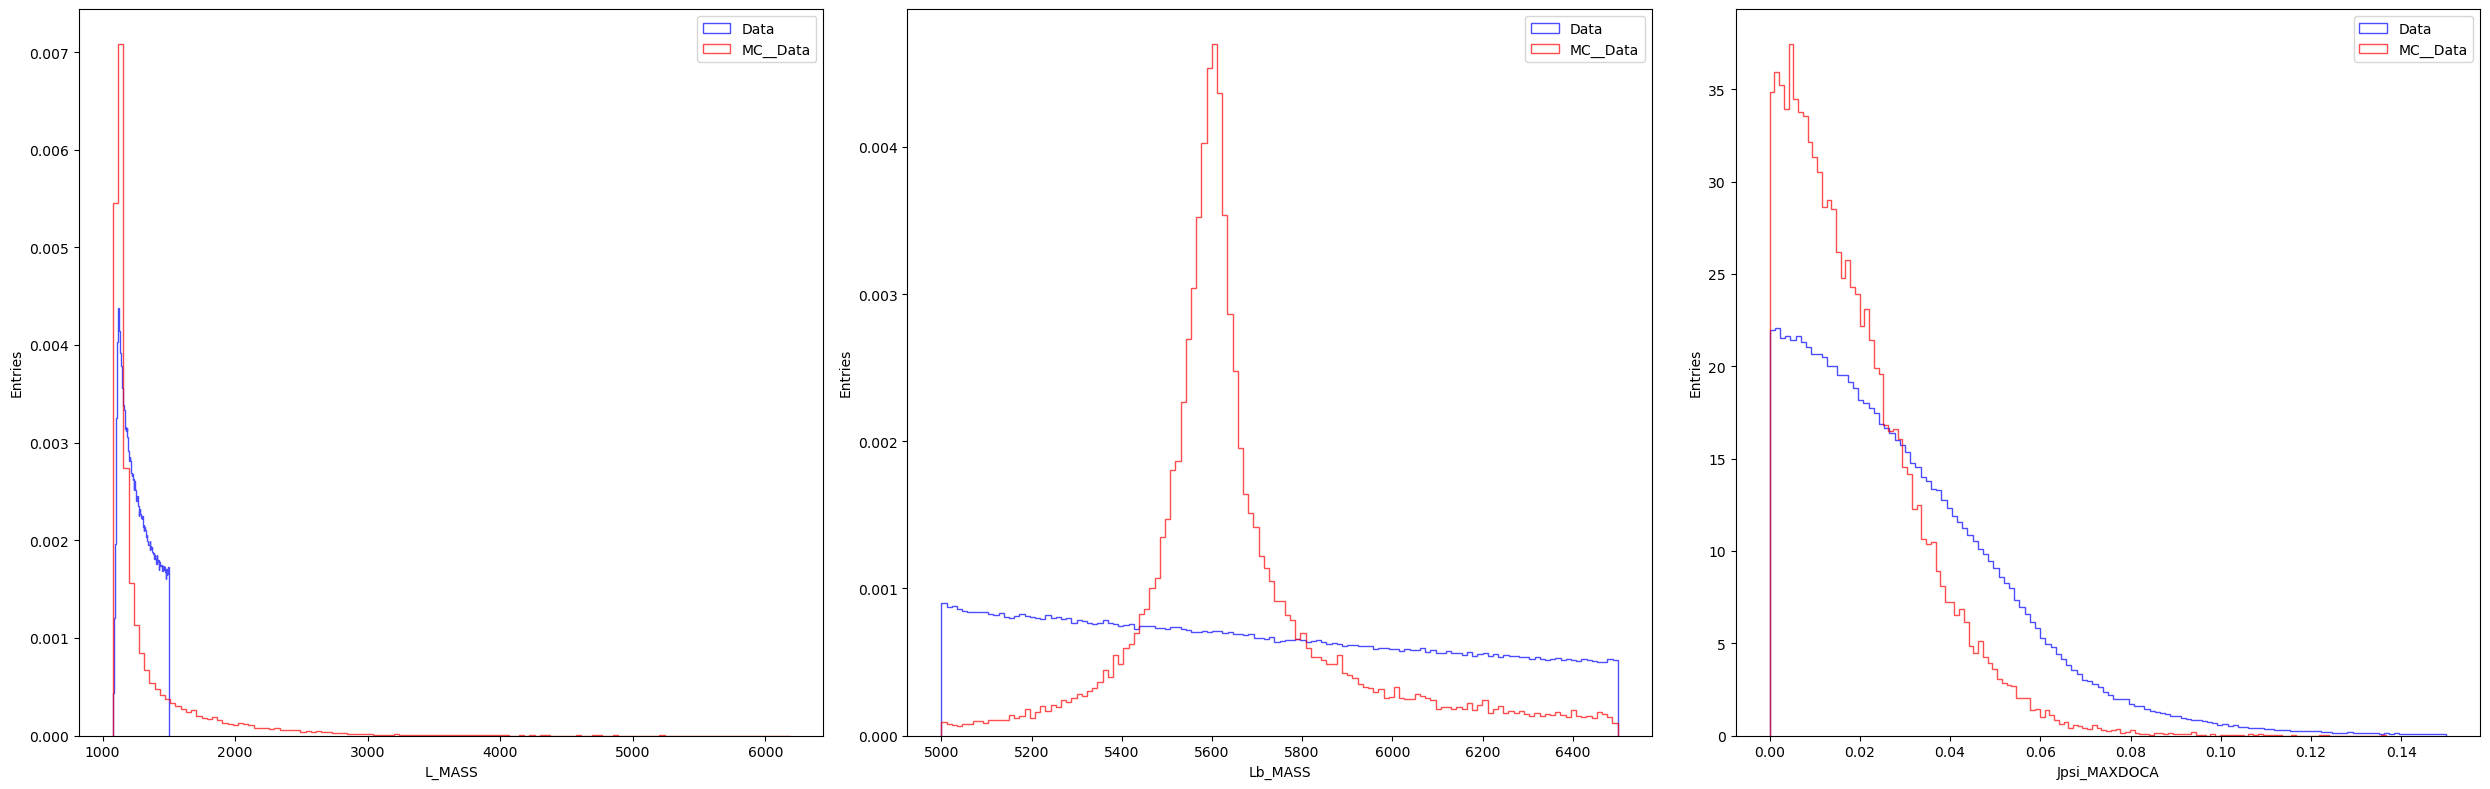

In [15]:
num_bins = 130

# Configuración de la figura y ejes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 8))

mass_varaibles = ['L_MASS','Lb_MASS', 'Jpsi_MAXDOCA']

# Iterar sobre las variables y graficar un histograma para cada una
for i, variable in enumerate(mass_varaibles):
    col = i % 4
    ax = axes[col]
    
    #ax.hist(signal_data_cut.query("(totCandidates ==1) & (prob > 0.9) & (Lb_P < 400000) & (Lb_PT < 30000) & (Lb_BPVIP < 0.2) & (Lb_BPVVDRHO < 4) & (Lb_CHI2 < 25) & (Lb_MAXDOCA < 50) & (L_BPVIP < 100) & (L_END_VRHO < 1200) & (L_MASS < 3000) & (p_MINIP < 350) & (p_PID_P < 60 ) & (p_PID_P > -30) & (p_P < 200000) & (p_PT < 14000) & (pim_P < 50000) & (pim_PT < 4000)& (totCandidates < 700)")[variable], bins=num_bins, label = 'totCandidates =1',  color='skyblue',alpha=0.7, density=True)
    if variable in ['Jpsi_BPVDIRA']:
        ax.hist(signal_data.query("(totCandidates == 1 ) & (Lb_BPVDIRA > 0.99997)")[variable], bins=np.linspace(0.99,1.005,100), label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal.query("(totCandidates == 1 )& (Lb_BPVDIRA > 0.99997)")[variable], bins=np.linspace(0.995,1.005,100), color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)

    else:
        ax.hist(signal_data.query("(totCandidates == 1 )")[variable], bins=num_bins, label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal.query("(totCandidates == 1 )")[variable], bins=num_bins, color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)
    
    ax.set_xlabel(variable)
    ax.set_ylabel('Entries')
    ax.legend()

plt.tight_layout()

plt.show()

In [16]:
len(total_keys2)

84

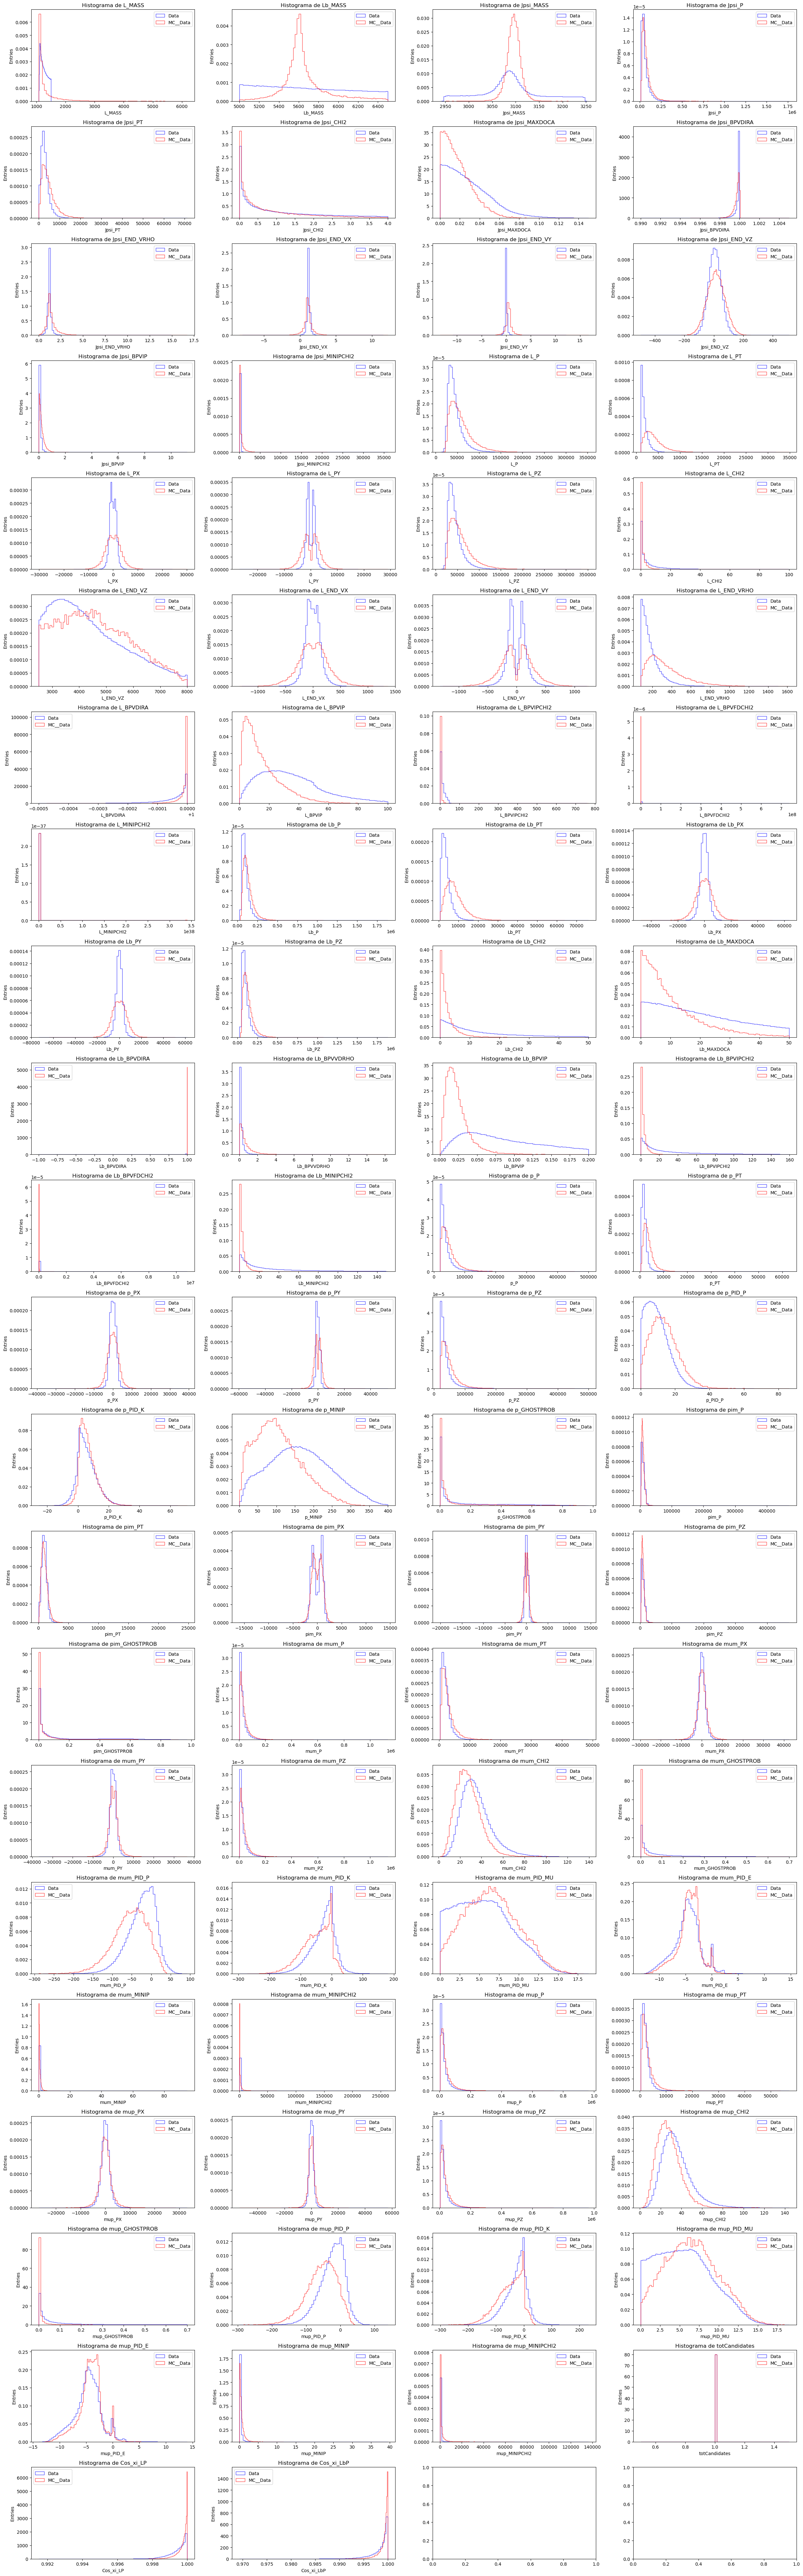

In [17]:
num_bins = 80

# Configuración de la figura y ejes
fig, axes = plt.subplots(nrows=22, ncols=4, figsize=(25, 80))

# Iterar sobre las variables y graficar un histograma para cada una
for i, variable in enumerate(total_keys2+['Cos_xi_LP']+['Cos_xi_LbP']):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    #ax.hist(signal_data_cut.query("(totCandidates ==1) & (prob > 0.9) & (Lb_P < 400000) & (Lb_PT < 30000) & (Lb_BPVIP < 0.2) & (Lb_BPVVDRHO < 4) & (Lb_CHI2 < 25) & (Lb_MAXDOCA < 50) & (L_BPVIP < 100) & (L_END_VRHO < 1200) & (L_MASS < 3000) & (p_MINIP < 350) & (p_PID_P < 60 ) & (p_PID_P > -30) & (p_P < 200000) & (p_PT < 14000) & (pim_P < 50000) & (pim_PT < 4000)& (totCandidates < 700)")[variable], bins=num_bins, label = 'totCandidates =1',  color='skyblue',alpha=0.7, density=True)
    if variable in ['Jpsi_BPVDIRA']:
        ax.hist(signal_data.query("(totCandidates == 1 ) & (Lb_BPVDIRA > 0.99997)")[variable], bins=np.linspace(0.99,1.005,100), label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal.query("(totCandidates == 1 )& (Lb_BPVDIRA > 0.99997)")[variable], bins=np.linspace(0.995,1.005,100), color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)

    else:
        ax.hist(signal_data.query("(totCandidates == 1 )")[variable], bins=num_bins, label = 'Data',  color='blue',alpha=0.7, histtype='step', density=True)
        ax.hist(mc_signal.query("(totCandidates == 1 )")[variable], bins=num_bins, color='red', label = 'MC__Data', histtype='step',alpha=0.7, density=True)
    
    ax.set_xlabel(variable)
    ax.set_ylabel('Entries')
    ax.set_title('Histograma de {}'.format(variable))
    ax.legend()

plt.tight_layout()

plt.show()

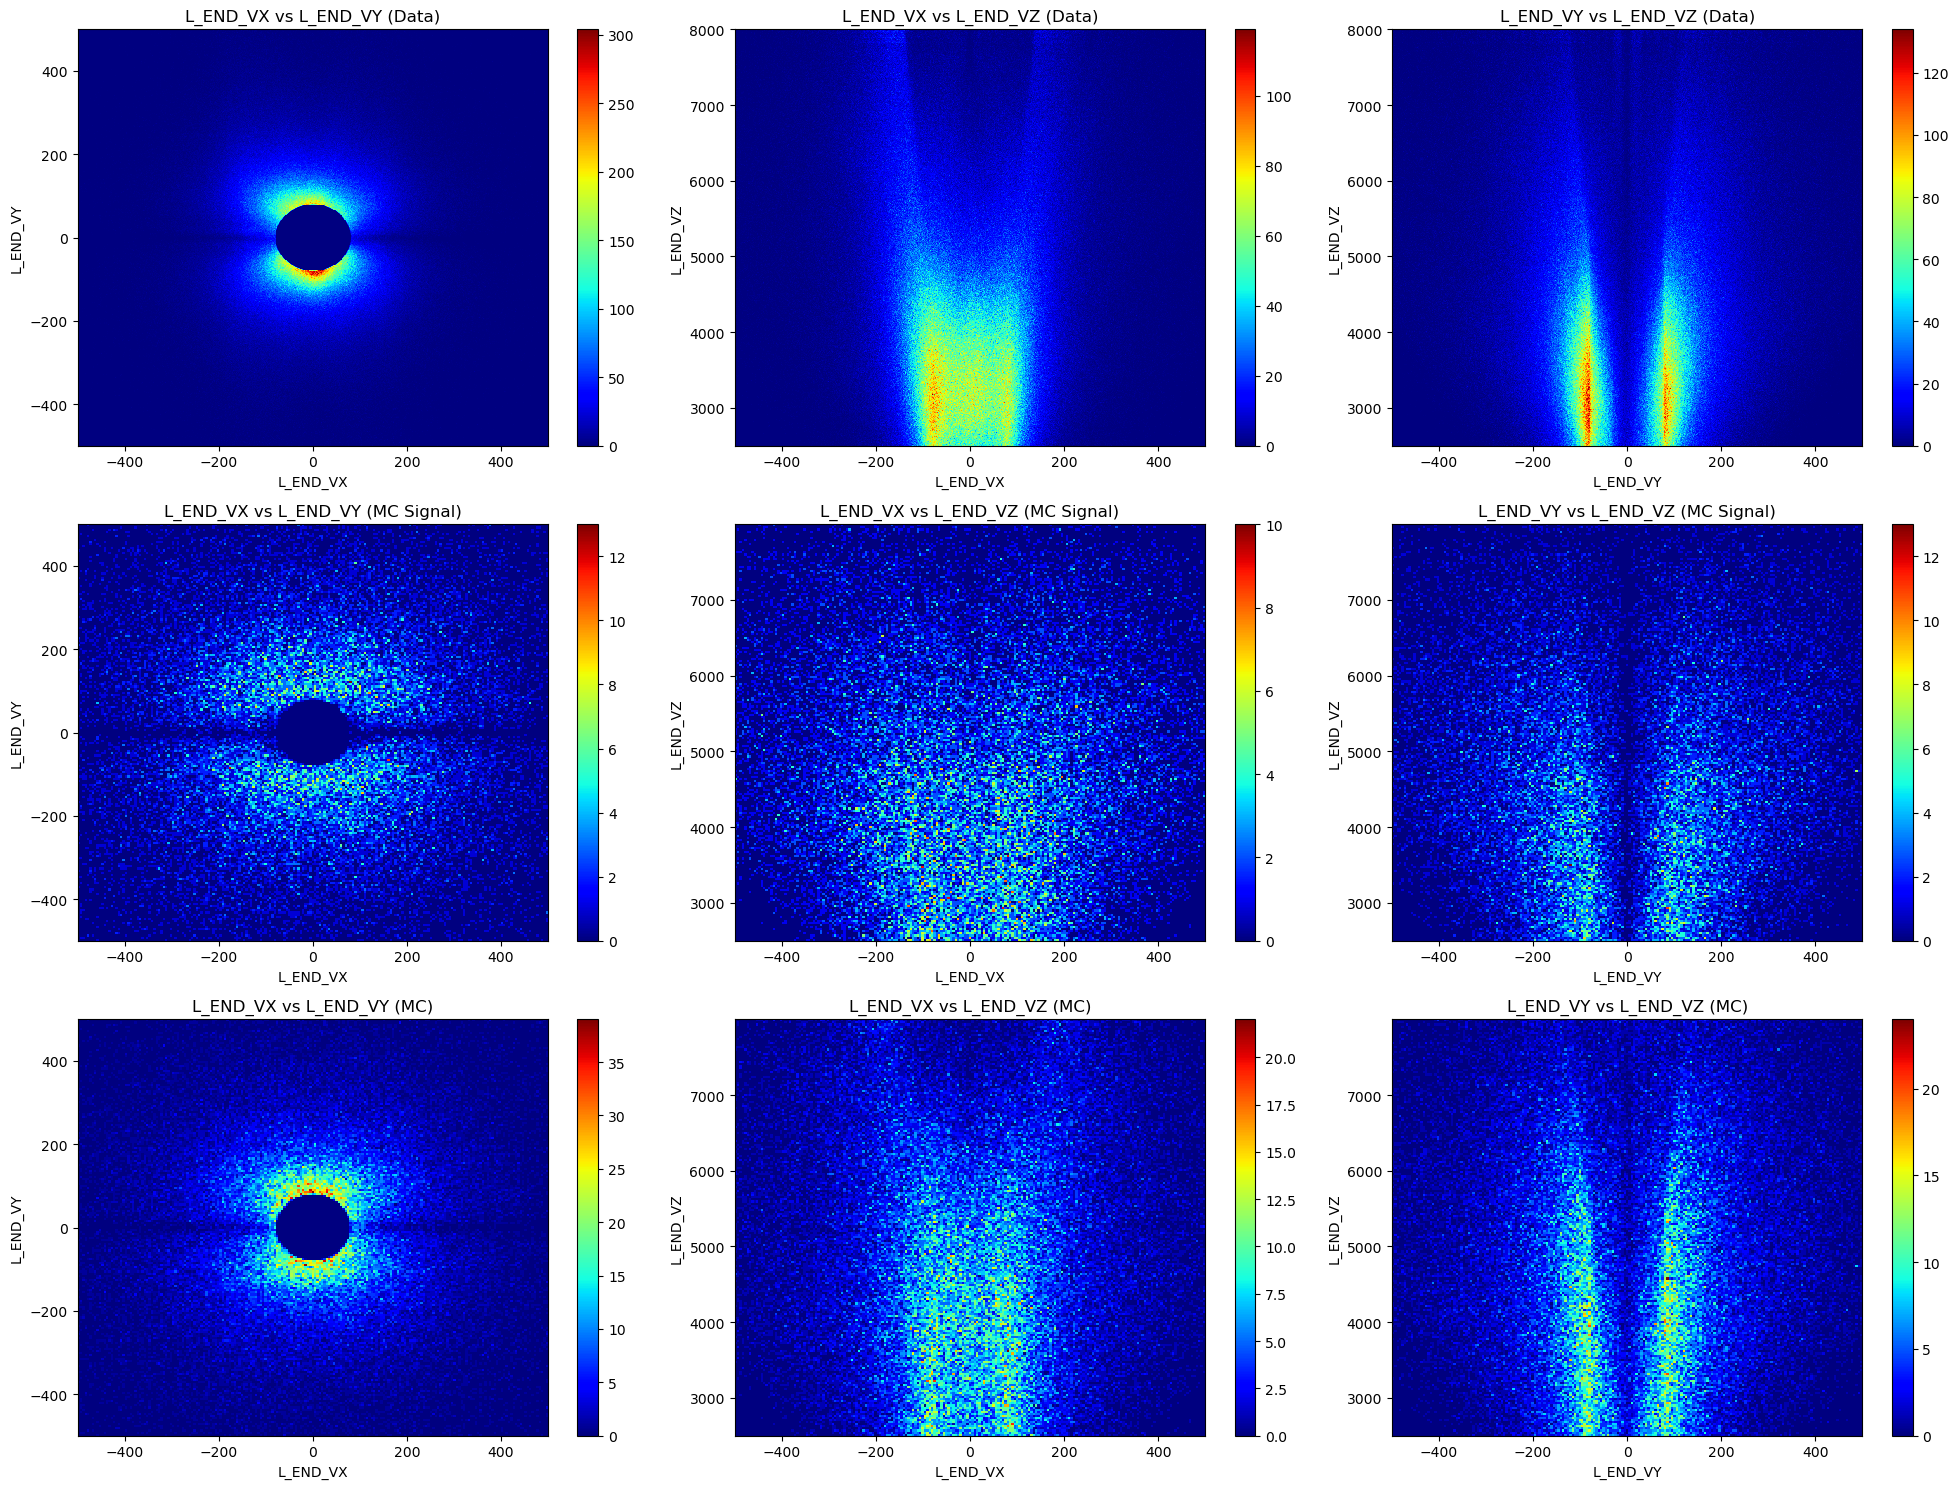

In [18]:
#Scattering Plots
x = signal_data['L_END_VX']
y = signal_data['L_END_VY']
z = signal_data['L_END_VZ']

x_mc = mc_signal['L_END_VX']
y_mc = mc_signal['L_END_VY']
z_mc = mc_signal['L_END_VZ']

x_mc2 = mc_signal_background['L_END_VX']
y_mc2 = mc_signal_background['L_END_VY']
z_mc2 = mc_signal_background['L_END_VZ']



# x_mc = mc_signal_background['L_END_VX']
# y_mc = mc_signal_background['L_END_VY']
# z_mc = mc_signal_background['L_END_VZ']

# x_mc = mc_background['L_END_VX']
# y_mc = mc_background['L_END_VY']
# z_mc = mc_background['L_END_VZ']

x_num_bins = np.linspace(-500,500,500)
x_num_bins_mc = np.linspace(-500,500,200)
y_num_bins = np.linspace(2500,8000,500)

# Crear subplots para los histogramas 2D
fig, axs = plt.subplots(3, 3, figsize=(20, 15))

#plt.cm.jet

# Histograma 2D de L_END_VX vs L_END_VY para signal_data
axs[0, 0].hist2d(x, y, bins=[x_num_bins,x_num_bins], cmin= 0,cmap = plt.cm.jet)
axs[0, 0].set_xlabel('L_END_VX')
axs[0, 0].set_ylabel('L_END_VY')
axs[0, 0].set_title('L_END_VX vs L_END_VY (Data)')
plt.colorbar(axs[0, 0].collections[0], ax=axs[0, 0])

# Histograma 2D de L_END_VX vs L_END_VZ para signal_data
axs[0, 1].hist2d(x, z, bins=[x_num_bins,y_num_bins], cmin= 0,cmap = plt.cm.jet)
axs[0, 1].set_xlabel('L_END_VX')
axs[0, 1].set_ylabel('L_END_VZ')
axs[0, 1].set_title('L_END_VX vs L_END_VZ (Data)')
plt.colorbar(axs[0, 1].collections[0], ax=axs[0, 1])

# Histograma 2D de L_END_VY vs L_END_VZ para signal_data
axs[0, 2].hist2d(y, z, bins=[x_num_bins,y_num_bins], cmin= 0,cmap = plt.cm.jet)
axs[0, 2].set_xlabel('L_END_VY')
axs[0, 2].set_ylabel('L_END_VZ')
axs[0, 2].set_title('L_END_VY vs L_END_VZ (Data)')
plt.colorbar(axs[0, 2].collections[0], ax=axs[0, 2])

# Histograma 2D de L_END_VX vs L_END_VY para mc_signal
axs[1, 0].hist2d(x_mc, y_mc, bins=[x_num_bins_mc,x_num_bins_mc], cmin= 0,cmap = plt.cm.jet)
axs[1, 0].set_xlabel('L_END_VX')
axs[1, 0].set_ylabel('L_END_VY')
axs[1, 0].set_title('L_END_VX vs L_END_VY (MC Signal)')
plt.colorbar(axs[1, 0].collections[0], ax=axs[1, 0])

# Histograma 2D de L_END_VX vs L_END_VZ para mc_signal
axs[1, 1].hist2d(x_mc, z_mc, bins=[x_num_bins_mc,200], cmin= 0,cmap = plt.cm.jet)
axs[1, 1].set_xlabel('L_END_VX')
axs[1, 1].set_ylabel('L_END_VZ')
axs[1, 1].set_title('L_END_VX vs L_END_VZ (MC Signal)')
plt.colorbar(axs[1, 1].collections[0], ax=axs[1, 1])

# Histograma 2D de L_END_VY vs L_END_VZ para mc_signal
axs[1, 2].hist2d(y_mc, z_mc, bins=[x_num_bins_mc,200], cmin= 0,cmap = plt.cm.jet)
axs[1, 2].set_xlabel('L_END_VY')
axs[1, 2].set_ylabel('L_END_VZ')
axs[1, 2].set_title('L_END_VY vs L_END_VZ (MC Signal)')
plt.colorbar(axs[1, 2].collections[0], ax=axs[1, 2])

# Histograma 2D de L_END_VX vs L_END_VY para mc_signal_background
axs[2, 0].hist2d(x_mc2, y_mc2, bins=[x_num_bins_mc,x_num_bins_mc], cmin= 0,cmap = plt.cm.jet)
axs[2, 0].set_xlabel('L_END_VX')
axs[2, 0].set_ylabel('L_END_VY')
axs[2, 0].set_title('L_END_VX vs L_END_VY (MC)')
plt.colorbar(axs[2, 0].collections[0], ax=axs[2, 0])

# Histograma 2D de L_END_VX vs L_END_VZ para mc_signal_background
axs[2, 1].hist2d(x_mc2, z_mc2, bins=[x_num_bins_mc,200], cmin= 0,cmap = plt.cm.jet)
axs[2, 1].set_xlabel('L_END_VX')
axs[2, 1].set_ylabel('L_END_VZ')
axs[2, 1].set_title('L_END_VX vs L_END_VZ (MC)')
plt.colorbar(axs[2, 1].collections[0], ax=axs[2, 1])

# Histograma 2D de L_END_VY vs L_END_VZ para mc_signal_background
axs[2, 2].hist2d(y_mc2, z_mc2, bins=[x_num_bins_mc,200], cmin= 0,cmap = plt.cm.jet)
axs[2, 2].set_xlabel('L_END_VY')
axs[2, 2].set_ylabel('L_END_VZ')
axs[2, 2].set_title('L_END_VY vs L_END_VZ (MC)')
plt.colorbar(axs[2, 2].collections[0], ax=axs[2, 2])

# Ajustar el layout para que no haya solapamiento
plt.tight_layout()

# Mostrar los gráficos
plt.show()

In [19]:
# import numpy as np

# # Datos proporcionados
# L_TRUEPX = mc_signal1['L_TRUEPX']
# L_TRUEPY = mc_signal1['L_TRUEPY']
# L_TRUEPZ = mc_signal1['L_TRUEPZ']
# L_TRUEENERGY = mc_signal1['L_TRUEENERGY']

# p_TRUEPX = mc_signal1['p_TRUEPX']
# p_TRUEPY = mc_signal1['p_TRUEPY']
# p_TRUEPZ = mc_signal1['p_TRUEPZ']
# p_TRUEENERGY = mc_signal1['p_TRUEENERGY']

# pim_TRUEPX = mc_signal1['pim_TRUEPX']
# pim_TRUEPY = mc_signal1['pim_TRUEPY']
# pim_TRUEPZ = mc_signal1['pim_TRUEPZ']
# pim_TRUEENERGY = mc_signal1['pim_TRUEENERGY']

# # Calcular la energía total y el momentum total del sistema
# L_TRUEP = np.sqrt(L_TRUEPX**2 + L_TRUEPY**2 + L_TRUEPZ**2)
# p_TRUEP = np.sqrt(p_TRUEPX**2 + p_TRUEPY**2 + p_TRUEPZ**2)
# pim_TRUEP = np.sqrt(pim_TRUEPX**2 + pim_TRUEPY**2 + pim_TRUEPZ**2)

# total_energy = L_TRUEENERGY + p_TRUEENERGY + pim_TRUEENERGY
# total_px = L_TRUEPX + p_TRUEPX + pim_TRUEPX
# total_py = L_TRUEPY + p_TRUEPY + pim_TRUEPY
# total_pz = L_TRUEPZ + p_TRUEPZ + pim_TRUEPZ

# # Calcular la velocidad de boost
# beta_x = np.sum(total_px) / np.sum(total_energy)
# beta_y = np.sum(total_py) / np.sum(total_energy)
# beta_z = np.sum(total_pz) / np.sum(total_energy)
# beta = np.array([beta_x, beta_y, beta_z])

# # Calcular el factor de Lorentz gamma
# gamma_factor = 1 / np.sqrt(1 - np.linalg.norm(beta)**2)

# # Crear la matriz de Lorentz boost
# boost_matrix = np.zeros((4, 4))
# boost_matrix[0, 0] = gamma_factor
# boost_matrix[1:, 0] = -gamma_factor * beta
# boost_matrix[0, 1:] = -gamma_factor * beta
# boost_matrix[1:, 1:] = np.eye(3) + (gamma_factor - 1) / np.linalg.norm(beta)**2 * np.outer(beta, beta)

# # Aplicar el boost a las cantidades de momentum y energía
# boosted_L_TRUE = np.dot(boost_matrix, np.array([L_TRUEPX, L_TRUEPY, L_TRUEPZ, L_TRUEENERGY]))
# boosted_p_TRUE = np.dot(boost_matrix, np.array([p_TRUEPX, p_TRUEPY, p_TRUEPZ, p_TRUEENERGY]))
# boosted_pim_TRUE = np.dot(boost_matrix, np.array([pim_TRUEPX, pim_TRUEPY, pim_TRUEPZ, pim_TRUEENERGY]))

# # Verificar los resultados
# print("Momentum y energía boosteados de Lambda:")
# print(boosted_L_TRUE)
# print("Momentum y energía boosteados de proton:")
# print(boosted_p_TRUE)
# print("Momentum y energía boosteados de pión:")
# print(boosted_pim_TRUE)


In [20]:
# import numpy as np
# import pandas as pd
# import vector  # Asumiendo que esto es una librería para manejo de vectores

# # Función para realizar el boost de Lorentz en el sistema de CM
# def perform_boost_cm(v0, v1, v2):
#     boost_vector = v0.to_beta3()
#     v1_boosted = v1.boostCM_of(boost_vector)
#     v2_boosted = v2.boostCM_of(boost_vector)
#     return v1_boosted, v2_boosted
# # Filtrar los datos
# mc_signal1 = mc_signal.query("(p_TRUEID == 2212) & (pim_TRUEID == -211)")
# mc_signal2 = mc_signal.query("(p_TRUEID == -2212) & (pim_TRUEID == 211)")
# # Calcular el momentum y la energía total del sistema en el centro de masa
# mc_signal1['total_px_CM'] = mc_signal1['L_TRUEPX'] + mc_signal1['p_TRUEPX'] + mc_signal1['pim_TRUEPX']
# mc_signal1['total_py_CM'] = mc_signal1['L_TRUEPY'] + mc_signal1['p_TRUEPY'] + mc_signal1['pim_TRUEPY']
# mc_signal1['total_pz_CM'] = mc_signal1['L_TRUEPZ'] + mc_signal1['p_TRUEPZ'] + mc_signal1['pim_TRUEPZ']
# mc_signal1['total_energy_CM'] = mc_signal1['L_TRUEENERGY'] + mc_signal1['p_TRUEENERGY'] + mc_signal1['pim_TRUEENERGY']

# # Calcular la velocidad de boost
# # beta_x = mc_signal1['total_px_CM'].mean() / mc_signal1['total_energy_CM'].mean()
# # beta_y = mc_signal1['total_py_CM'].mean() / mc_signal1['total_energy_CM'].mean()
# beta_z = mc_signal1['total_pz_CM'].mean() / mc_signal1['total_energy_CM'].mean()

# # Aplicar el boost a cada partícula individual
# for particle in ['L', 'p', 'pim']:
#     mc_signal1[f'{particle}_TRUEPX_CM'] = mc_signal1[f'{particle}_TRUEPX']
#     mc_signal1[f'{particle}_TRUEPY_CM'] = mc_signal1[f'{particle}_TRUEPY']
#     mc_signal1[f'{particle}_TRUEPZ_CM'] = mc_signal1[f'{particle}_TRUEPZ']
#     mc_signal1[f'{particle}_TRUEENERGY_CM'] = mc_signal1[f'{particle}_TRUEENERGY']

#     # mc_signal1[f'{particle}_TRUEPX_CM'] = gamma_factor * (mc_signal1[f'{particle}_TRUEPX'] - beta_x * mc_signal1[f'{particle}_TRUEENERGY'])
#     # mc_signal1[f'{particle}_TRUEPY_CM'] = gamma_factor * (mc_signal1[f'{particle}_TRUEPY'] - beta_y * mc_signal1[f'{particle}_TRUEENERGY'])
#     mc_signal1[f'{particle}_TRUEPZ_CM'] = gamma_factor * (mc_signal1[f'{particle}_TRUEPZ'] - beta_z * mc_signal1[f'{particle}_TRUEENERGY'])
#     # mc_signal1[f'{particle}_TRUEENERGY_CM'] = gamma_factor * (mc_signal1[f'{particle}_TRUEENERGY'] - beta_x * mc_signal1[f'{particle}_TRUEPX'] - beta_y * mc_signal1[f'{particle}_TRUEPY'] - beta_z * mc_signal1[f'{particle}_TRUEPZ'])
#     mc_signal1[f'{particle}_TRUEENERGY_CM'] = gamma_factor * (mc_signal1[f'{particle}_TRUEENERGY'] - beta_z * mc_signal1[f'{particle}_TRUEPZ'])

# # # Calculate the components of the displacement vector
# # dx1 = mc_signal1['L_END_VX'] - mc_signal1['Jpsi_END_VX']
# # dy1 = mc_signal1['L_END_VY'] - mc_signal1['Jpsi_END_VY']
# # dz1 = mc_signal1['L_END_VZ'] - mc_signal1['Jpsi_END_VZ']

# # # Calculate the distance d
# # d1 = np.sqrt(dx1**2 + dy1**2 + dz1**2)

# # # Calculate the unit vector components
# # nx1 = dx1 / d1
# # ny1 = dy1 / d1
# # nz1 = dz1 / d1

# nx1 = mc_signal1['L_TRUEPX_CM'] / np.sqrt(mc_signal1['L_TRUEPX_CM']**2 + mc_signal1['L_TRUEPY_CM']**2 + mc_signal1['L_TRUEPZ_CM']**2)
# ny1 = mc_signal1['L_TRUEPY_CM'] / np.sqrt(mc_signal1['L_TRUEPX_CM']**2 + mc_signal1['L_TRUEPY_CM']**2 + mc_signal1['L_TRUEPZ_CM']**2)
# nz1 = mc_signal1['L_TRUEPZ_CM'] / np.sqrt(mc_signal1['L_TRUEPX_CM']**2 + mc_signal1['L_TRUEPY_CM']**2 + mc_signal1['L_TRUEPZ_CM']**2)


# nx4 = mc_signal2['L_TRUEPX']/mc_signal2['L_TRUEP']
# ny4 = mc_signal2['L_TRUEPY']/mc_signal2['L_TRUEP']
# nz4 = mc_signal2['L_TRUEPZ']/mc_signal2['L_TRUEP']

# # Calculate the longitudinal momentum on the direction of motion
# p_L_plus1 = (mc_signal1['p_TRUEPX_CM'] * nx1) + (mc_signal1['p_TRUEPY_CM'] * ny1) + (mc_signal1['p_TRUEPZ_CM'] * nz1)
# p_L_minus1 = (mc_signal1['pim_TRUEPX_CM'] * nx1) + (mc_signal1['pim_TRUEPY_CM'] * ny1) + (mc_signal1['pim_TRUEPZ_CM'] * nz1)

# alpha_L1 = (p_L_plus1 - p_L_minus1) / (p_L_plus1 + p_L_minus1)

# # Calculate the pT 
# pt1 = np.sqrt((mc_signal1['p_TRUEPX_CM'] - p_L_plus1 * nx1)**2 + (mc_signal1['p_TRUEPY_CM'] - p_L_plus1 * ny1)**2 + (mc_signal1['p_TRUEPZ_CM'] - p_L_plus1 * nz1)**2)


In [21]:
particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'
# Filtrar los datos
# mc_signal1 = mc_signal.query(particulas)
# mc_signal2 = mc_signal.query(antiparticulas)

mc_signal1 = signal_data.query(particulas)
mc_signal2 = signal_data.query(antiparticulas)


nx3 = mc_signal1['L_PX']/mc_signal1['L_P']
ny3 = mc_signal1['L_PY']/mc_signal1['L_P']
nz3 = mc_signal1['L_PZ']/mc_signal1['L_P']

nx4 = mc_signal2['L_PX']/mc_signal2['L_P']
ny4 = mc_signal2['L_PY']/mc_signal2['L_P']
nz4 = mc_signal2['L_PZ']/mc_signal2['L_P']

# Calculate de longitudinal momentum on the direction of motion
p_L_plus1 = ( mc_signal1['p_PX']*nx3)+( mc_signal1['p_PY']*ny3)+( mc_signal1['p_PZ']*nz3)
p_L_minus1 = ( mc_signal1['pim_PX']*nx3)+( mc_signal1['pim_PY']*ny3)+( mc_signal1['pim_PZ']*nz3)

p_L_plus2 = ( mc_signal2['pim_PX']*nx4)+( mc_signal2['pim_PY']*ny4)+( mc_signal2['pim_PZ']*nz4)
p_L_minus2 = ( mc_signal2['p_PX']*nx4)+( mc_signal2['p_PY']*ny4)+( mc_signal2['p_PZ']*nz4)

alpha_L1 = (p_L_plus1-p_L_minus1)/(p_L_plus1+p_L_minus1)
alpha_L2 = (p_L_plus2-p_L_minus2)/(p_L_plus2+p_L_minus2)


# Calculate the pT 
pt1 = np.sqrt((mc_signal1['p_PX']- p_L_plus1*nx3)**2+(mc_signal1['p_PY']- p_L_plus1*ny3)**2+(mc_signal1['p_PZ']- p_L_plus1*nz3)**2 )
pt2 = np.sqrt((mc_signal2['pim_PX']- p_L_plus2*nx4)**2+(mc_signal2['pim_PY']- p_L_plus2*ny4)**2+(mc_signal2['pim_PZ']- p_L_plus2*nz4)**2 )
# pt2 = np.sqrt((mc_signal2['p_TRUEPX']- p_L_plus2*nx4)**2+(mc_signal2['pim_TRUEPY']- p_L_plus2*ny4)**2+(mc_signal2['pim_TRUEPZ']- p_L_plus2*nz4)**2 )

/tmp/javeser/ipykernel_31081/609428295.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


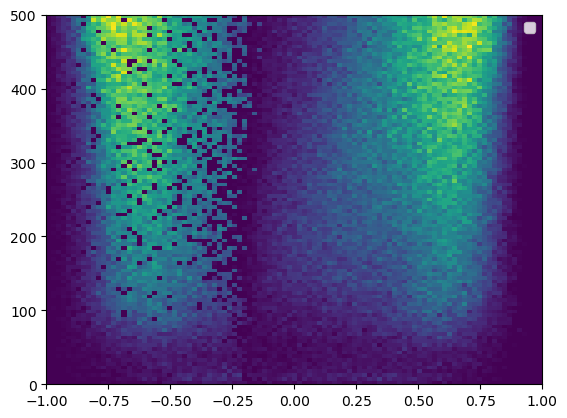

In [22]:
x_num_bins = np.linspace(-1,1,100)
y_num_bins = np.linspace(0,500,100)


# alpha_L_mc = pd.merge(alpha_L2, alpha_L1, how= 'outer')
# pt_mc = pd.merge(pt1, pt2, how= 'outer')

fig, ax = plt.subplots()
ax.hist2d(alpha_L2,pt2,bins= [x_num_bins,y_num_bins], label = 'Lambda', cmin= 0)
ax.hist2d(alpha_L1,pt1,bins= [x_num_bins,y_num_bins], label = 'Lambda', cmin= 0.05)
plt.legend()
plt.show()

In [23]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

# Filtrar los datos según las condiciones dadas
mc_signal3 = mc_signal.query("(p_TRUEID == 2212) & (pim_TRUEID == -211) & (p_MC_GD_MOTHER_ID == 5122) & (pim_MC_GD_MOTHER_ID == 5122) & (p_MC_MOTHER_ID == 3122) & (pim_MC_MOTHER_ID == 3122)")
mc_signal4 = mc_signal.query("(p_TRUEID == -2212) & (pim_TRUEID == 211) & (p_MC_GD_MOTHER_ID == -5122) & (pim_MC_GD_MOTHER_ID == -5122) & (p_MC_MOTHER_ID == -3122) & (pim_MC_MOTHER_ID == -3122)")

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
results_mass = []
results_mass_p = []
results_mass_pion = []
results_mass_lambda = []

for index, row in mc_signal3.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    results_mass.append(mass)
    results_mass_p.append(mass_p)
    results_mass_pion.append(mass_pion)
    results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
results_mass = []  # Reinicializar la lista de masas
results_mass_p = []
results_mass_pion = []
results_mass_lambda = []

for index, row in mc_signal4.iterrows():
    pV0_4 = [row['L_TRUEPX'], row['L_TRUEPY'], row['L_TRUEPZ'], row['L_TRUEENERGY']]
    pplus_4 = [row['p_TRUEPX'], row['p_TRUEPY'], row['p_TRUEPZ'], row['p_TRUEENERGY']]
    pminus_4 = [row['pim_TRUEPX'], row['pim_TRUEPY'], row['pim_TRUEPZ'], row['pim_TRUEENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    results_mass.append(mass)
    results_mass_p.append(mass_p)
    results_mass_pion.append(mass_pion)
    results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_antiparticle_true = pd.DataFrame(results, columns=['alpha', 'pT'])
invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle_true)
print("\nMasa invariante de la Lambda:")
print(invariant_mass_particle)
print("\nMasa invariante del Proton:")
print(invariant_mass_particle_p)
print("\nMasa invariante del Pion:")
print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle_true)
print("\nMasa invariante de la Anti-Lambda:")
print(invariant_mass_antiparticle)
print("\nMasa invariante del Anti-Proton:")
print(invariant_mass_antiparticle_p)
print("\nMasa invariante del Anti-Pion:")
print(invariant_mass_antiparticle_pion)


Welcome to JupyROOT 6.30/04
Partículas:
          alpha          pT
0      0.821004   70.045893
1      0.722349   99.104053
2      0.762896   92.387073
3      0.824587   67.942600
4      0.699481  100.486159
...         ...         ...
20439  0.816155   72.727660
20440  0.751065   94.957348
20441  0.823050   68.858291
20442  0.871542    6.427363
20443  0.846235   51.736179

[20444 rows x 2 columns]

Masa invariante de la Lambda:
              mass
0      1116.070041
1      1116.289973
2      1115.580483
3      1115.767076
4      1115.725888
...            ...
20439  1115.524024
20440  1115.682224
20441  1115.709013
20442  1115.922864
20443  1115.639634

[20444 rows x 1 columns]

Masa invariante del Proton:
           p_mass
0      938.678192
1      938.896801
2      938.155412
3      938.351615
4      938.314566
...           ...
20439  938.114547
20440  938.270144
20441  938.291112
20442  938.575950
20443  938.245905

[20444 rows x 1 columns]

Masa invariante del Pion:
         pim_ma

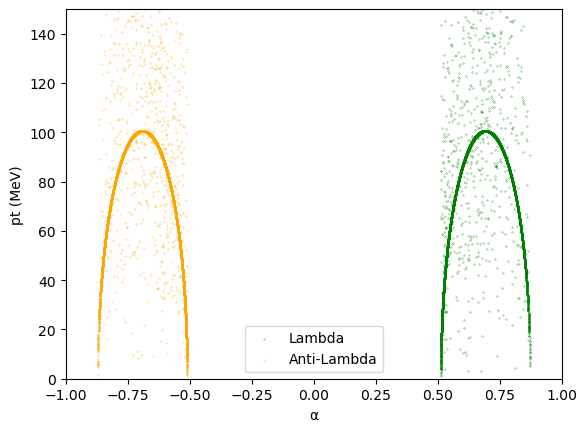

In [24]:

fig, ax = plt.subplots()
# ax.scatter(armenteros_particle['alpha'], armenteros_particle['pT'], c= 'green',s=0.05, label = 'Lambda')
# ax.scatter(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], c= 'orange',s=0.05, label = 'Anti-Lambda')
ax.scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c= 'green',s=0.05, label = 'Lambda')
ax.scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c= 'orange',s=0.05, label = 'Anti-Lambda')
# Ajustar los límites de los ejes
ax.set_xlim(-1, 1)
ax.set_ylim(0, 150)
plt.xlabel('α')
plt.ylabel('pt (MeV)')
plt.legend()
plt.show()

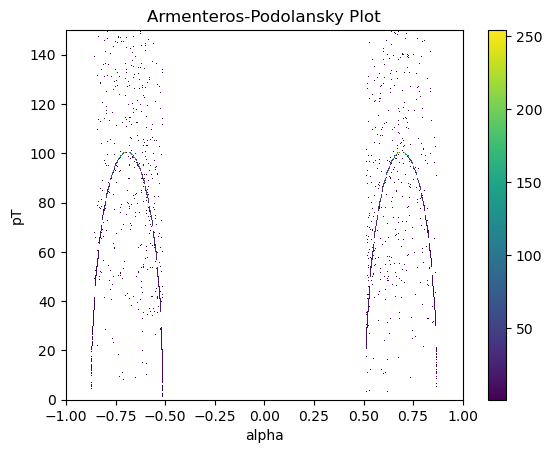

In [25]:
x_num_bins = np.linspace(-1,1,500)
y_num_bins = np.linspace(0,150,500)


# alpha_L_mc = pd.merge(alpha_L2, alpha_L1, how= 'outer')
# pt_mc = pd.merge(pt1, pt2, how= 'outer')

fig, ax = plt.subplots()
h1 = ax.hist2d(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], bins=[x_num_bins, y_num_bins], label='Lambda', cmin=0.1)
h2 = ax.hist2d(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], bins=[x_num_bins, y_num_bins], label='Anti-Lambda', cmin=0.1)

plt.colorbar(h1[3], ax=ax)

plt.xlabel('alpha')
plt.ylabel('pT')
plt.title('Armenteros-Podolansky Plot')
plt.show()

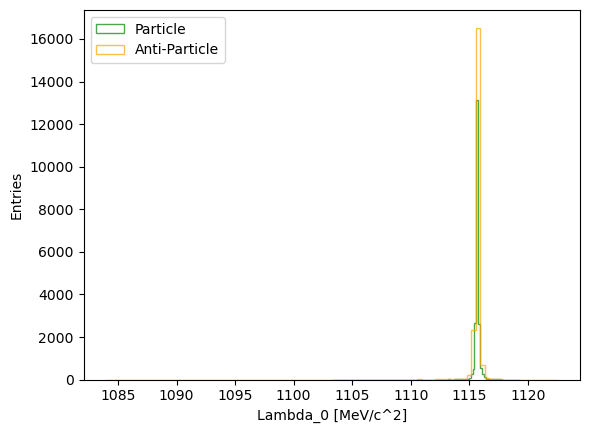

In [26]:
fig,axes = plt.subplots()
plt.hist(invariant_mass_particle,bins= 100 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
plt.hist(invariant_mass_antiparticle,bins= 100 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
plt.xlabel('Lambda_0 [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()
plt.show()

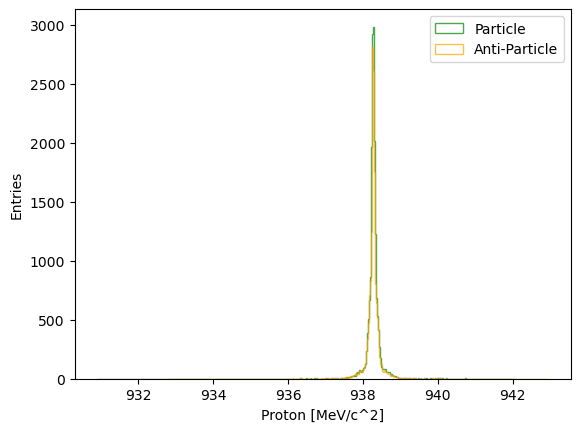

In [27]:
fig,axes = plt.subplots()

plt.hist(invariant_mass_particle_p,bins= 500 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
plt.hist(invariant_mass_antiparticle_p,bins= 500 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
plt.xlabel('Proton [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()
plt.show()

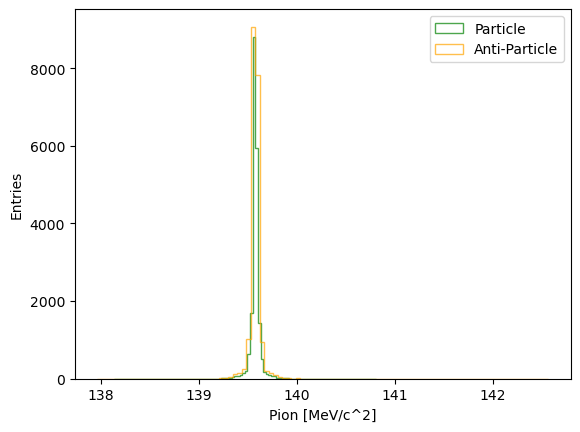

In [28]:
fig,axes = plt.subplots()

plt.hist(invariant_mass_particle_pion,bins= 100 , label = 'Particle',  color='green',alpha=0.7, histtype='step')
plt.hist(invariant_mass_antiparticle_pion,bins= 100 , label = 'Anti-Particle',  color='orange',alpha=0.7, histtype='step')
plt.xlabel('Pion [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()
plt.show()

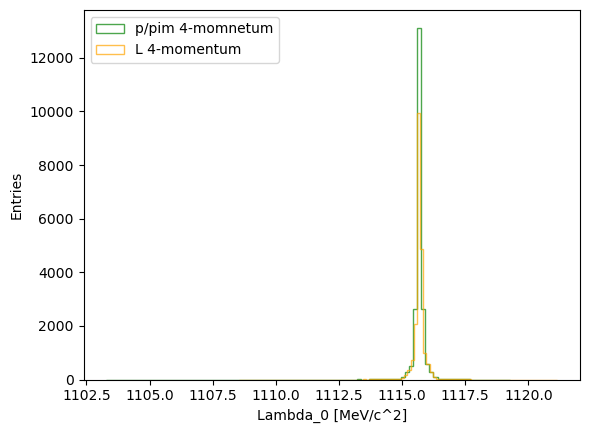

In [29]:
fig,axes = plt.subplots()
plt.hist(invariant_mass_particle,bins= 100 , label = 'p/pim 4-momnetum',  color='green',alpha=0.7, histtype='step')
plt.hist(invariant_mass_particle_lambda,bins= 100 , label = 'L 4-momentum',  color='orange',alpha=0.7, histtype='step')
plt.xlabel('Lambda_0 [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()
plt.show()

In [30]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle_mc = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle_mc = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle_mc)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle_mc)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


Partículas:
          alpha           pT
0      0.732200  1014.093428
1      0.771027   137.126079
2      0.774729   157.215224
3      0.738094    84.237050
4      0.744465   409.743237
...         ...          ...
20439  0.933086  1990.715869
20440  0.899065  1850.924014
20441  0.899724  1089.973003
20442  0.926110  1222.965974
20443  0.936781  1864.975569

[20444 rows x 2 columns]

Antipartículas:
          alpha           pT
0     -0.738908   201.324198
1     -0.767569   174.075016
2     -0.715373  1043.609841
3     -0.724536   561.458247
4     -0.751067   290.299948
...         ...          ...
20005 -0.920527   839.906641
20006 -0.906575  1328.836212
20007 -0.891205   939.470005
20008 -0.878844  1070.170837
20009 -0.893270  1271.866684

[20010 rows x 2 columns]


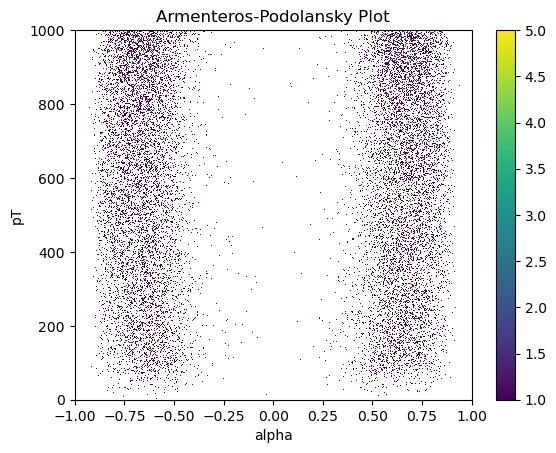

In [31]:
x_num_bins = np.linspace(-1,1,500)
y_num_bins = np.linspace(0,1000,500)


# alpha_L_mc = pd.merge(alpha_L2, alpha_L1, how= 'outer')
# pt_mc = pd.merge(pt1, pt2, how= 'outer')

fig, ax = plt.subplots()
h1 = ax.hist2d(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], bins=[x_num_bins, y_num_bins], label='Lambda', cmin=0.01)
h2 = ax.hist2d(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], bins=[x_num_bins, y_num_bins], label='Anti-Lambda', cmin=0.001)

plt.colorbar(h1[3], ax=ax)

plt.xlabel('alpha')
plt.ylabel('pT')
plt.title('Armenteros-Podolansky Plot')
plt.show()

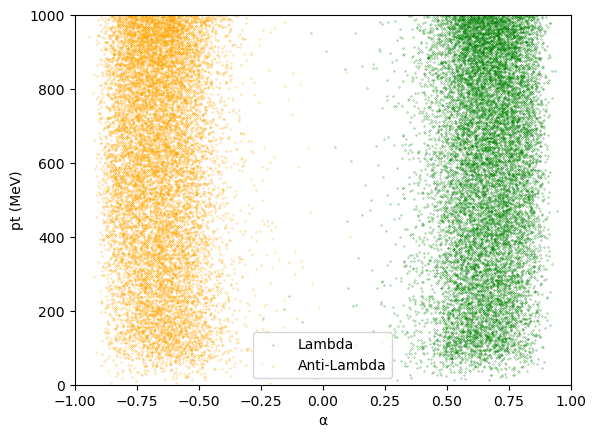

In [32]:
fig, ax = plt.subplots()
# ax.scatter(armenteros_particle['alpha'], armenteros_particle['pT'], c= 'green',s=0.05, label = 'Lambda')
# ax.scatter(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], c= 'orange',s=0.05, label = 'Anti-Lambda')
ax.scatter(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], c= 'green',s=0.05, label = 'Lambda', alpha=1)
ax.scatter(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], c= 'orange',s=0.05, label = 'Anti-Lambda', alpha=1)
# Ajustar los límites de los ejes
ax.set_xlim(-1, 1)
ax.set_ylim(0, 1000)
plt.xlabel('α')
plt.ylabel('pt (MeV)')
plt.legend()
plt.show()

In [33]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = signal_data.query(particulas)
mc_signal2 = signal_data.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


Partículas:
            alpha           pT
0        0.481488  1097.490031
1        0.804836   810.881737
2        0.643629  1387.023387
3        0.680566   889.608918
4        0.632618   978.468667
...           ...          ...
1191115  0.265156  1048.970652
1191116  0.338156  1019.463729
1191117  0.475547   964.047702
1191118  0.354256   994.047075
1191119  0.940065  4912.844555

[1191120 rows x 2 columns]

Antipartículas:
            alpha           pT
0       -0.761464   884.124833
1       -0.774860   982.846771
2       -0.412306  1144.954177
3       -0.605809   973.881565
4       -0.807814  1063.530822
...           ...          ...
1194400 -0.336585  1862.667363
1194401 -0.807904  1600.864083
1194402 -0.795762   831.114940
1194403 -0.764979   874.367543
1194404 -0.794895   414.466434

[1194405 rows x 2 columns]


/tmp/javeser/ipykernel_31081/1816256586.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/l/javeser/micromamba/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


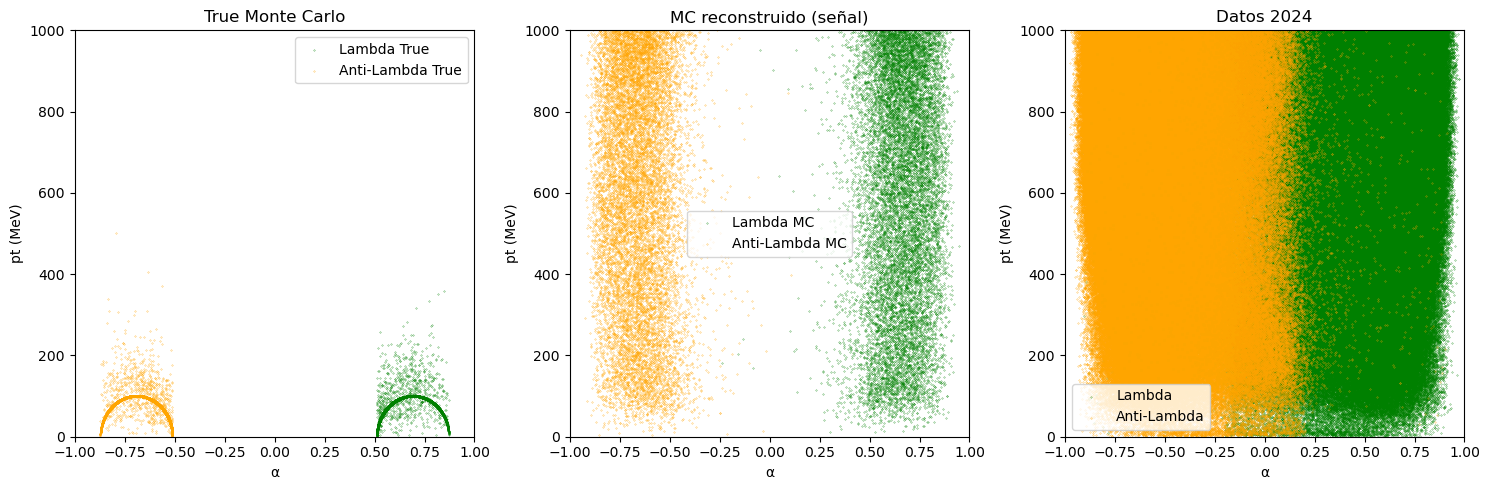

In [34]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# Primer gráfico
axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 1000)
axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].scatter(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], c='green', s=0.05, label='Lambda MC')
axs[1].scatter(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], c='orange', s=0.05, label='Anti-Lambda MC')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 1000)
axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# Tercer gráfico
axs[2].scatter(armenteros_particle['alpha'], armenteros_particle['pT'], c='green', s=0.05, label='Lambda')
axs[2].scatter(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], c='orange', s=0.05, label='Anti-Lambda')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 1000)
axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()


/tmp/javeser/ipykernel_31081/3379843745.py:11: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[0].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/javeser/ipykernel_31081/3379843745.py:20: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[1].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/javeser/ipykernel_31081/3379843745.py:29: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axs[2].legend()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


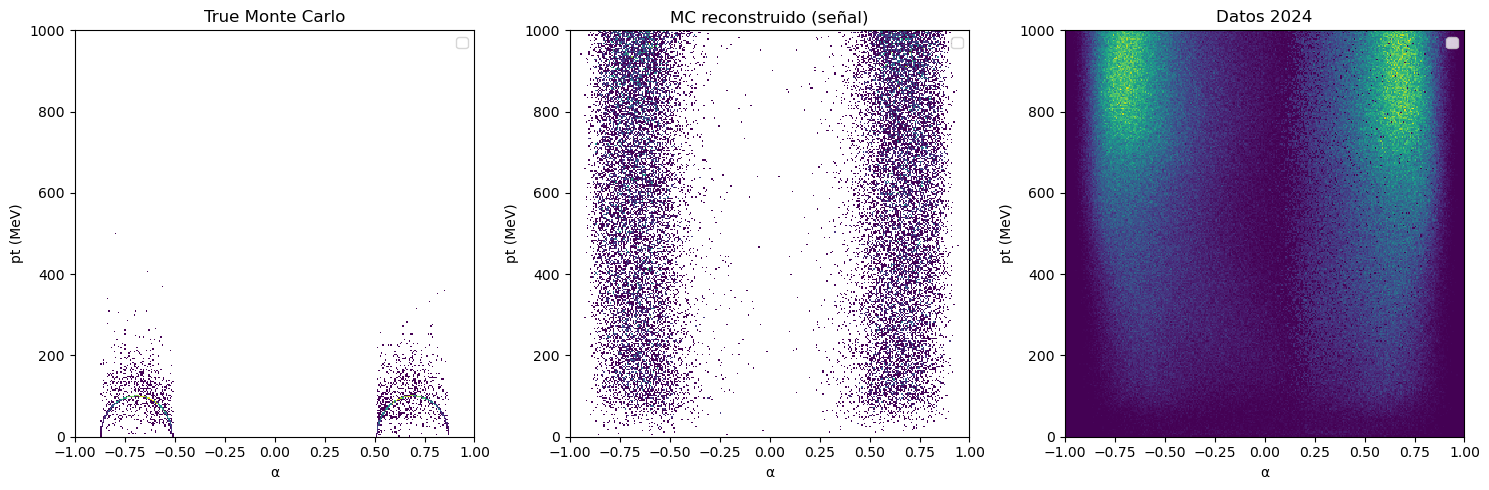

In [35]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

x_num_bins = np.linspace(-1,1,300)
y_num_bins = np.linspace(0,1000,300)
# Primer gráfico
axs[0].hist2d(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], bins=[x_num_bins,y_num_bins], label='Lambda True', cmin=0.01)
axs[0].hist2d(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda True', cmin=0.01)

axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].hist2d(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], bins=[x_num_bins,y_num_bins], label='Lambda MC', cmin=0.01)
axs[1].hist2d(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'],bins=[x_num_bins,y_num_bins], label='Anti-Lambda MC', cmin=0.01)

axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# Tercer gráfico
axs[2].hist2d(armenteros_particle['alpha'], armenteros_particle['pT'],bins=[x_num_bins,y_num_bins], label='Lambda', cmin=0.0)
axs[2].hist2d(armenteros_antiparticle['alpha'], armenteros_antiparticle['pT'], bins=[x_num_bins,y_num_bins], label='Anti-Lambda', cmin=0.01)

axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('Datos 2024')

plt.tight_layout()
plt.show()

In [36]:
model = CatBoostClassifier().load_model("new_BDT")

In [37]:
model.feature_names_

['Jpsi_PT',
 'L_END_VRHO',
 'L_BPVDIRA',
 'L_BPVIP',
 'L_BPVIPCHI2',
 'Lb_BPVDIRA',
 'Lb_BPVIP',
 'Lb_BPVVDRHO',
 'Lb_MAXDOCA',
 'Lb_P',
 'Lb_PT',
 'Lb_CHI2',
 'p_PID_P',
 'p_MINIP',
 'mup_PID_MU',
 'L_PT',
 'Jpsi_MAXDOCA',
 'Lb_MINIPCHI2',
 'L_P',
 'Jpsi_BPVDIRA',
 'L_CHI2',
 'Lb_ETA',
 'L_END_VZ',
 'L_END_VX',
 'L_END_VY',
 'Jpsi_ETA',
 'p_P',
 'p_PT',
 'p_ETA',
 'p_GHOSTPROB',
 'pim_P',
 'pim_PT',
 'pim_ETA',
 'pim_GHOSTPROB',
 'SUMCHI2',
 'xi_LbP',
 'xi_LP']

In [38]:
prob = model.predict_proba(signal_data)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
signal_data['prob1'] = signal_MVA_probs

[[9.99987904e-01 1.20963185e-05]
 [9.99332239e-01 6.67761136e-04]
 [9.99999914e-01 8.59043065e-08]
 ...
 [9.98824410e-01 1.17559000e-03]
 [9.99229614e-01 7.70386479e-04]
 [9.99782202e-01 2.17797735e-04]]


/tmp/javeser/ipykernel_31081/1477103308.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  signal_data['prob1'] = signal_MVA_probs


In [39]:
model2 = CatBoostClassifier().load_model("new_BDT_multiclass")
prob2 = model2.predict_proba(signal_data)
print(prob2)

signal_MVA_prob_eval2 = prob2
signal_MVA_probs2 = [1 - i[0] for i in signal_MVA_prob_eval2]
signal_data['prob2'] = signal_MVA_probs2

[[9.99716695e-01 2.83304855e-04]
 [9.99671435e-01 3.28565296e-04]
 [9.99993240e-01 6.75966969e-06]
 ...
 [9.98770799e-01 1.22920076e-03]
 [9.97422796e-01 2.57720372e-03]
 [9.99394455e-01 6.05545195e-04]]


/tmp/javeser/ipykernel_31081/2591102298.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  signal_data['prob2'] = signal_MVA_probs2


In [40]:
len(signal_data)

2385525

NameError: name 'n_sig' is not defined

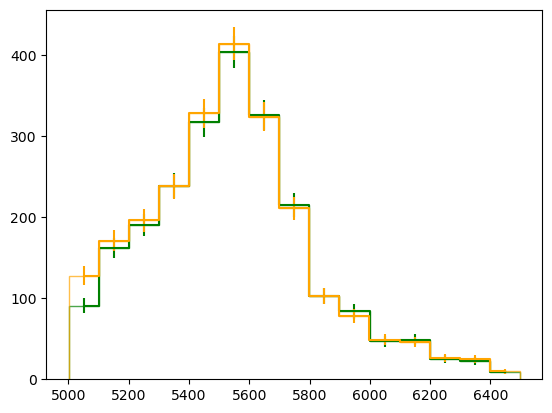

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()


hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.99)')['Lb_MASS'],bins=15,label='Binary',color='green',alpha=0.7,histtype='step')
hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'],bins=15,label='MultiClass',color='orange',alpha=0.7,histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    color='green',
    drawstyle='steps-mid'
)

# Plot error bars for the second histogram
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    color='orange',
    drawstyle='steps-mid'
)

plt.errorbar( 0.5*(bins1[1:] + bins1[:-1]), n_sig, yerr=np.sqrt(n_sig),drawstyle = 'steps-mid',fmt='o',color='blue',label="Data")
# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')

plt.ylabel('Entries')
plt.legend()
plt.show()


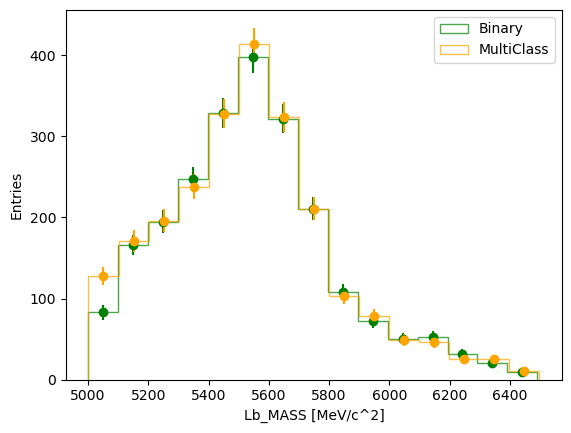

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()

# Plot histograms
hist1, bins1, _ = axes.hist(signal_data.query('(prob1 > 0.99)')['Lb_MASS'], bins=15, label='Binary', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(signal_data.query('(prob2 > 0.99)')['Lb_MASS'], bins=15, label='MultiClass', color='orange', alpha=0.7, histtype='step')

# Calculate the bin centers for the error bars
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# Plot error bars for the first histogram
axes.errorbar(
    bin_centers1,
    hist1,
    yerr=np.sqrt(hist1),
    fmt='o',
    color='green',
    # label='Binary Data',
    drawstyle='steps-mid'
)

# Plot error bars for the second histogram
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    fmt='o',
    color='orange',
    # label='MultiClass Data',
    drawstyle='steps-mid'
)

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [ ]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = signal_data.query(particulas)
mc_signal2 = signal_data.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Inicializar columnas para almacenar los resultados
signal_data['alpha'] = np.nan
signal_data['pT'] = np.nan
signal_data['alpha_anti'] = np.nan
signal_data['pT_anti'] = np.nan

# Calcular para partículas
particle = True

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'alpha'] = alpha
    signal_data.at[index, 'pT'] = pT

# Calcular para antipartículas
particle = False

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX'], row['p_PY'], row['p_PZ'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX'], row['pim_PY'], row['pim_PZ'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    signal_data.at[index, 'alpha_anti'] = alpha
    signal_data.at[index, 'pT_anti'] = pT

# Mostrar resultados
print("Datos actualizados:")
print(signal_data[['alpha', 'pT']].dropna())


Datos actualizados:
            alpha           pT
0        0.481488  1097.490031
1        0.804836   810.881737
2        0.643629  1387.023387
6        0.680566   889.608918
8        0.632618   978.468667
...           ...          ...
2385516  0.265156  1048.970652
2385517  0.338156  1019.463729
2385518  0.475547   964.047702
2385519  0.354256   994.047075
2385520  0.940065  4912.844555

[1191120 rows x 2 columns]


In [ ]:
from rk_transport import FarRKTrkTransport, propagate_to_vertex

def propagate_to_vertex(vz, xi, yi, zi, pxi, pyi, pzi, qoverp,rk):
    xf,yf,txf,tyf = rk.propagate(vz/10., 1., xi/10., yi/10., zi/10., pxi/1000., pyi/1000., pzi/1000., qoverp*1000.)
    mom = np.array([txf,tyf,1])*((np.abs(1/(qoverp*1000.)))/np.sqrt(txf**2. + tyf**2. + 1.))
    return mom[0]*1000., mom[1]*1000., mom[2]*1000., xf*10., yf*10.

rk = FarRKTrkTransport()

vertex_values = pd.DataFrame(columns=['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V'])
vertex_values2 = pd.DataFrame(columns=['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V'])

vertex_values[['p_PX_V','p_PY_V','p_PZ_V','p_X_V','p_Y_V']] = mc_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.p_TRACK_POS_CLOSESTTOBEAM_X,row.p_TRACK_POS_CLOSESTTOBEAM_Y,row.p_TRACK_POS_CLOSESTTOBEAM_Z,row.p_PX,row.p_PY,row.p_PZ,row.p_QOVERP,rk),axis='columns',result_type='expand')
vertex_values2[['pim_PX_V','pim_PY_V','pim_PZ_V','pim_X_V','pim_Y_V']] = mc_signal.apply(lambda row: propagate_to_vertex(row.L_END_VZ,row.pim_TRACK_POS_CLOSESTTOBEAM_X,row.pim_TRACK_POS_CLOSESTTOBEAM_Y,row.pim_TRACK_POS_CLOSESTTOBEAM_Z,row.pim_PX,row.pim_PY,row.pim_PZ,row.pim_QOVERP,rk),axis='columns',result_type='expand')

mc_signal = pd.concat([mc_signal,vertex_values],axis='columns')
mc_signal = pd.concat([mc_signal,vertex_values2],axis='columns')


FarRKTrkTransport: reading B field mapping from file /l/javeser/farvertexing/db/MagneticFieldMapping20x20x100.root
FarRKTrkTransport: reading B field mapping with: x in [-300,300] and 21 points
                                                 y in [-300,300] and 21 points
                                                 z in [0,1000] and 101 points


In [ ]:
mc_signal.columns

Index(['L_MASS', 'Lb_MASS', 'Jpsi_MASS', 'Jpsi_P', 'Jpsi_PT', 'Jpsi_CHI2',
       'Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'Jpsi_END_VRHO', 'Jpsi_END_VX',
       ...
       'p_PX_V', 'p_PY_V', 'p_PZ_V', 'p_X_V', 'p_Y_V', 'pim_PX_V', 'pim_PY_V',
       'pim_PZ_V', 'pim_X_V', 'pim_Y_V'],
      dtype='object', length=138)

In [ ]:
import ROOT
from ROOT import TVector3, TLorentzVector
import pandas as pd

particulas = ' (p_QOVERP > 0) & (pim_QOVERP < 0 )'
antiparticulas = ' (p_QOVERP < 0) & (pim_QOVERP > 0)'

mc_signal1 = mc_signal.query(particulas)
mc_signal2 = mc_signal.query(antiparticulas)

def calculate_AP(particle, pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector 
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Convertir TLorentzVector a TVector3
    pV0 = pV0_4.Vect()
    pplus = pplus_4.Vect()
    pminus = pminus_4.Vect()
    
    # Dirección de vuelo
    u = pV0.Unit()
    
    # Calcular alpha
    pLplus = pplus.Dot(u) if particle else pminus.Dot(u)
    pLminus = pminus.Dot(u) if particle else pplus.Dot(u)
    alpha = (pLplus - pLminus) / (pLplus + pLminus)
    
    # Calcular pT
    pTplus = (pplus - pLplus * u).Mag() if particle else (pplus - pLminus * u).Mag()
    pTminus = (pminus - pLminus * u).Mag() if particle else (pminus - pLplus * u).Mag()
    
    # pT debería ser el mismo para pTplus y pTminus
    pT = pTplus
    
    return alpha, pT

def calculate_invariant_mass(pV0_4, pplus_4, pminus_4):
    # Convertir listas a TLorentzVector si es necesario
    if isinstance(pV0_4, list):
        pV0_4 = TLorentzVector(*pV0_4)
    if isinstance(pplus_4, list):
        pplus_4 = TLorentzVector(*pplus_4)
    if isinstance(pminus_4, list):
        pminus_4 = TLorentzVector(*pminus_4)
    
    # Sumar los cuadrimomentos
    total_momentum = pplus_4 + pminus_4
    
    # Calcular la masa invariante
    invariant_mass = total_momentum.M()
    invariant_mass_pion = pminus_4.M()
    invariant_mass_proton = pplus_4.M()
    invariant_mass_lambda = pV0_4.M()
    
    return invariant_mass, invariant_mass_proton, invariant_mass_pion, invariant_mass_lambda

# Calcular para partículas
particle = True
results = []
# results_mass = []
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal1.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# Convertir resultados a DataFrame
armenteros_particle = pd.DataFrame(results, columns=['alpha', 'pT'])
# invariant_mass_particle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_particle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_particle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_particle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Calcular para antipartículas
particle = False
results = []  # Reinicializar la lista de resultados
# results_mass = []  # Reinicializar la lista de masas
# results_mass_p = []
# results_mass_pion = []
# results_mass_lambda = []

for index, row in mc_signal2.iterrows():
    pV0_4 = [row['L_PX'], row['L_PY'], row['L_PZ'], row['L_ENERGY']]
    pplus_4 = [row['p_PX_V'], row['p_PY_V'], row['p_PZ_V'], row['p_ENERGY']]
    pminus_4 = [row['pim_PX_V'], row['pim_PY_V'], row['pim_PZ_V'], row['pim_ENERGY']]
    
    alpha, pT = calculate_AP(particle, pV0_4, pplus_4, pminus_4)
    # mass, mass_p, mass_pion, mass_lambda = calculate_invariant_mass(pV0_4, pplus_4, pminus_4)
    results.append((alpha, pT))
    # results_mass.append(mass)
    # results_mass_p.append(mass_p)
    # results_mass_pion.append(mass_pion)
    # results_mass_lambda.append(mass_lambda)

# # Convertir resultados a DataFrame
armenteros_antiparticle = pd.DataFrame(results, columns=['alpha_anti', 'pT_anti'])
# invariant_mass_antiparticle = pd.DataFrame(results_mass, columns=['mass'])
# invariant_mass_antiparticle_p = pd.DataFrame(results_mass_p, columns=['p_mass'])
# invariant_mass_antiparticle_pion = pd.DataFrame(results_mass_pion, columns=['pim_mass'])
# invariant_mass_antiparticle_lambda = pd.DataFrame(results_mass_lambda, columns=['l_mass'])

# Mostrar resultados
print("Partículas:")
print(armenteros_particle)
# print("\nMasa invariante de la Lambda:")
# print(invariant_mass_particle)
# print("\nMasa invariante del Proton:")
# print(invariant_mass_particle_p)
# print("\nMasa invariante del Pion:")
# print(invariant_mass_particle_pion)

print("\nAntipartículas:")
print(armenteros_antiparticle)
# print("\nMasa invariante de la Anti-Lambda:")
# print(invariant_mass_antiparticle)
# print("\nMasa invariante del Anti-Proton:")
# print(invariant_mass_antiparticle_p)
# print("\nMasa invariante del Anti-Pion:")
# print(invariant_mass_antiparticle_pion)


Partículas:
          alpha           pT
0      0.737765  2134.859993
1      0.771389   978.988023
2      0.775257   331.669601
3      0.738294   236.321746
4      0.744366   455.269274
...         ...          ...
16870  0.452662  1601.213577
16871  0.776143  1770.982640
16872  0.576195  1610.743651
16873  0.868186  2103.236277
16874  0.818647   155.364315

[16875 rows x 2 columns]

Antipartículas:
       alpha_anti      pT_anti
0       -0.738943   308.890926
1       -0.768207   879.562668
2       -0.714315    98.272883
3       -0.731342  1374.918459
4       -0.751013    17.127572
...           ...          ...
16520   -0.765650  1964.953994
16521   -0.430212   193.671575
16522   -0.864263   697.365180
16523   -0.815103  1848.863905
16524   -0.804924   111.875574

[16525 rows x 2 columns]


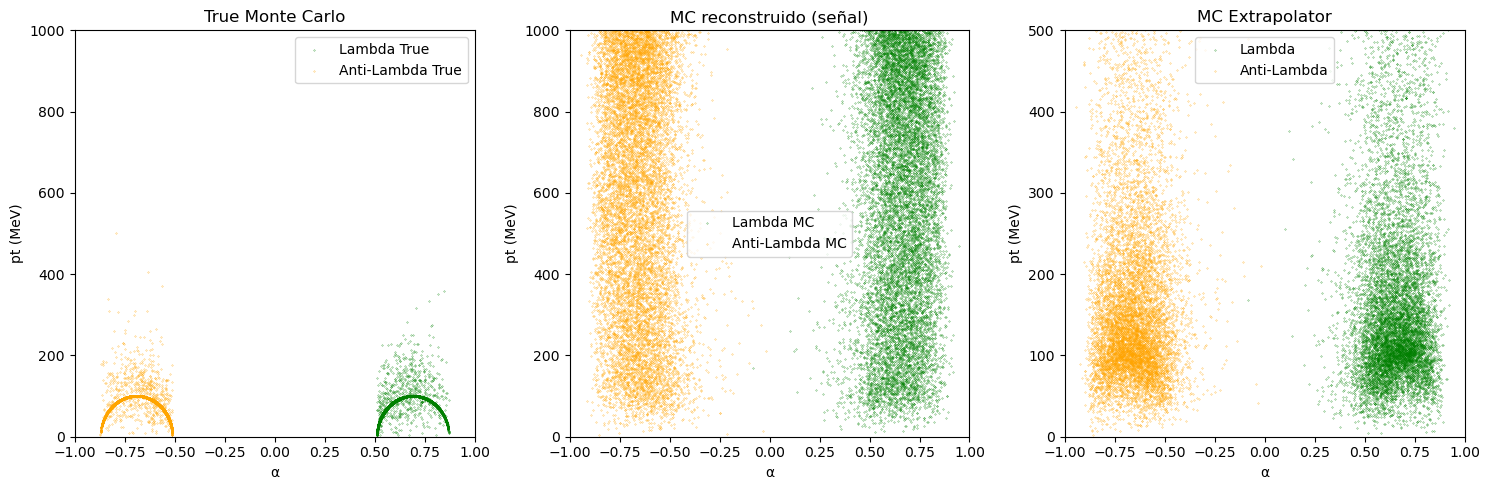

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 3 filas, 1 columna

# Primer gráfico
axs[0].scatter(armenteros_particle_true['alpha'], armenteros_particle_true['pT'], c='green', s=0.05, label='Lambda True')
axs[0].scatter(armenteros_antiparticle_true['alpha'], armenteros_antiparticle_true['pT'], c='orange', s=0.05, label='Anti-Lambda True')
axs[0].set_xlim(-1, 1)
axs[0].set_ylim(0, 1000)
axs[0].set_xlabel('α')
axs[0].set_ylabel('pt (MeV)')
axs[0].legend()
axs[0].set_title('True Monte Carlo')

# Segundo gráfico
axs[1].scatter(armenteros_particle_mc['alpha'], armenteros_particle_mc['pT'], c='green', s=0.05, label='Lambda MC')
axs[1].scatter(armenteros_antiparticle_mc['alpha'], armenteros_antiparticle_mc['pT'], c='orange', s=0.05, label='Anti-Lambda MC')
axs[1].set_xlim(-1, 1)
axs[1].set_ylim(0, 1000)
axs[1].set_xlabel('α')
axs[1].set_ylabel('pt (MeV)')
axs[1].legend()
axs[1].set_title('MC reconstruido (señal)')

# Tercer gráfico
axs[2].scatter(armenteros_particle['alpha'],armenteros_particle['pT'], c='green', s=0.05, label='Lambda')
axs[2].scatter(armenteros_antiparticle['alpha_anti'],armenteros_antiparticle['pT_anti'], c='orange', s=0.05, label='Anti-Lambda')
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 500)
axs[2].set_xlabel('α')
axs[2].set_ylabel('pt (MeV)')
axs[2].legend()
axs[2].set_title('MC Extrapolator')

plt.tight_layout()
plt.show()
